# HW04-ICA :: Part B (PyTorch CNN on MNIST)

COSC 6373

Adam Nelson-Archer, 2140122

In [ ]:
from __future__ import annotations

import os
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 6373
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Reproducibility (best-effort)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
print("CWD:", os.getcwd())

PyTorch: 2.5.1+cu121
CUDA available: True
Device: cuda
CWD: c:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B


In [2]:
# Data directory
# Prefer reusing Part A's downloaded dataset if present.
NOTEBOOK_DIR = Path.cwd()
PART_A_DATA_DIR = (NOTEBOOK_DIR / ".." / "Part_A" / "data").resolve()
LOCAL_DATA_DIR = (NOTEBOOK_DIR / "data").resolve()

DATA_DIR = PART_A_DATA_DIR if PART_A_DATA_DIR.exists() else LOCAL_DATA_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)

# MNIST loaders
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

full_train_ds = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

# 10% validation split
n_total = len(full_train_ds)
n_val = int(0.10 * n_total)
n_train = n_total - n_val

train_ds, val_ds = random_split(
    full_train_ds,
    lengths=[n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

x0, y0 = full_train_ds[0]
print("One sample tensor shape:", tuple(x0.shape), "label:", y0)

DATA_DIR: C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.55MB/s]


Extracting C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw\train-images-idx3-ubyte.gz to C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 875kB/s]

Extracting C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw\train-labels-idx1-ubyte.gz to C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw

...

100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]


Extracting C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw\t10k-images-idx3-ubyte.gz to C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]

Extracting C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw\t10k-labels-idx1-ubyte.gz to C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW4\Part_B\data\MNIST\raw



Train size: 54000
Val size: 6000
Test size: 10000
One sample tensor shape: (1, 28, 28) label: 5


In [4]:
def make_loaders(batch_size: int):
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader, test_loader


def get_activation(name: str) -> nn.Module:
    """Keep activations minimal (per HW requirements)."""
    name = name.lower().strip()
    if name == "relu":
        return nn.ReLU()
    if name in {"leaky_relu", "lrelu", "leaky"}:
        return nn.LeakyReLU(negative_slope=0.01)
    raise ValueError(f"Unknown activation: {name}")

In [5]:
class BaseMNISTCNN(nn.Module):
    """Base CNN for MNIST (Part A architecture).

    Spec pipeline:
    Convolutional Layer -> MaxPooling -> Flatten -> Dropout -> Fully Connected layer
    """

    def __init__(
        self,
        num_classes: int = 10,
        dropout_p: float = 0.5,
        activation: str = "relu",
    ):
        super().__init__()
        self.act = get_activation(activation)

        # 1x28x28 -> 16x24x24 (kernel=5, no padding)
        self.conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5)

        # 16x24x24 -> 16x12x12
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten: 16 * 12 * 12 = 2304
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(16 * 12 * 12, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.act(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


class DeeperMNISTCNN(nn.Module):
    """Deeper CNN variant for Part B.

    Example: 3x Conv blocks + pooling, then a small MLP head.
    """

    def __init__(
        self,
        num_classes: int = 10,
        dropout_p: float = 0.5,
        activation: str = "relu",
    ):
        super().__init__()
        self.act = get_activation(activation)

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 28x28
        self.pool1 = nn.MaxPool2d(2, 2)                           # 14x14

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 14x14
        self.pool2 = nn.MaxPool2d(2, 2)                           # 7x7

        self.dropout = nn.Dropout(p=dropout_p)
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool1(x)
        x = self.act(self.conv3(x))
        x = self.pool2(x)
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [6]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    loss_fn: nn.Module,
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = loss_fn(logits, y)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += x.size(0)

    avg_loss = total_loss / max(total_seen, 1)
    avg_acc = total_correct / max(total_seen, 1)
    return avg_loss, avg_acc


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float = 1e-3,
):
    """Minimal training loop: Adam + CrossEntropyLoss."""
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_acc": [],
        "val_acc": [],
        "epoch_seconds": [],
    }

    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        _, tr_acc = run_epoch(model, train_loader, optimizer, loss_fn)
        _, va_acc = run_epoch(model, val_loader, None, loss_fn)
        dt = time.perf_counter() - t0

        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["epoch_seconds"].append(dt)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train acc={tr_acc:.4f} | val acc={va_acc:.4f} | {dt:.1f}s"
        )

    return model, history


def evaluate_and_confusion(model: nn.Module, loader: DataLoader, num_classes: int = 10):
    model.eval()
    model.to(device)

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    total_correct = 0
    total_seen = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            total_correct += (preds == y).sum().item()
            total_seen += x.size(0)

            preds_np = preds.cpu().numpy()
            y_np = y.cpu().numpy()
            for t, p in zip(y_np, preds_np):
                cm[int(t), int(p)] += 1

    acc = total_correct / max(total_seen, 1)
    return acc, cm

In [ ]:
import matplotlib.pyplot as plt


def plot_confusion_matrix(cm: np.ndarray, title: str):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(10))
    plt.yticks(range(10))

    for (i, j), v in np.ndenumerate(cm):
        if v != 0:
            plt.text(j, i, str(v), ha="center", va="center", fontsize=8)

    plt.tight_layout()

## Baseline model (Part A)

- epochs: 10
- validation split: 10%
- batch_size=32, optimizer = Adam, dropout = 0.5, activation = ReLU

In [8]:
# Baseline training config (Part A model)
BASE_EPOCHS = 10
BASE_BATCH_SIZE = 32
BASE_DROPOUT = 0.5
BASE_ACTIVATION = "relu"

train_loader, val_loader, test_loader = make_loaders(batch_size=BASE_BATCH_SIZE)

base_model = BaseMNISTCNN(dropout_p=BASE_DROPOUT, activation=BASE_ACTIVATION)
print(base_model)

base_model, base_hist = train_model(
    base_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=BASE_EPOCHS,
    lr=1e-3,
)

print("Avg seconds/epoch:", float(np.mean(base_hist["epoch_seconds"])))
print("Last val accuracy:", float(base_hist["val_acc"][-1]))

BaseMNISTCNN(
  (act): ReLU()
  (conv): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=2304, out_features=10, bias=True)
)
Epoch 01/10 | train acc=0.9309 | val acc=0.9782 | 19.5s
Epoch 02/10 | train acc=0.9652 | val acc=0.9837 | 20.4s
Epoch 03/10 | train acc=0.9709 | val acc=0.9830 | 19.7s
Epoch 04/10 | train acc=0.9753 | val acc=0.9855 | 20.3s
Epoch 05/10 | train acc=0.9764 | val acc=0.9868 | 18.8s
Epoch 06/10 | train acc=0.9786 | val acc=0.9858 | 19.2s
Epoch 07/10 | train acc=0.9804 | val acc=0.9853 | 18.4s
Epoch 08/10 | train acc=0.9810 | val acc=0.9867 | 19.6s
Epoch 09/10 | train acc=0.9814 | val acc=0.9873 | 19.4s
Epoch 10/10 | train acc=0.9821 | val acc=0.9875 | 18.1s
Avg seconds/epoch: 19.32612123000008
Last val accuracy: 0.9875


Baseline test accuracy: 0.9867


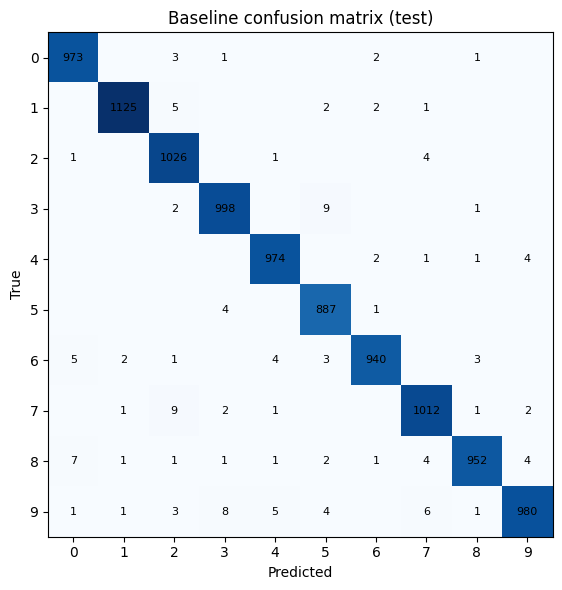

In [9]:
# Baseline evaluation
base_test_acc, base_cm = evaluate_and_confusion(base_model, test_loader, num_classes=10)
print(f"Baseline test accuracy: {base_test_acc:.4f}")
plot_confusion_matrix(base_cm, title="Baseline confusion matrix (test)")

## Deeper CNN (added conv layers) + experiments

DeeperMNISTCNN(
  (act): ReLU()
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=6272, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Epoch 01/10 | train acc=0.9499 | val acc=0.9860 | 23.3s
Epoch 02/10 | train acc=0.9777 | val acc=0.9888 | 26.0s
Epoch 03/10 | train acc=0.9824 | val acc=0.9908 | 23.8s
Epoch 04/10 | train acc=0.9856 | val acc=0.9913 | 26.1s
Epoch 05/10 | train acc=0.9881 | val acc=0.9913 | 24.3s
Epoch 06/10 | train acc=0.9886 | val acc=0.9910 | 23.7s
Epoch 07/10 | train acc=0.9895 | val acc=0.9935 | 23.0s
Epoc

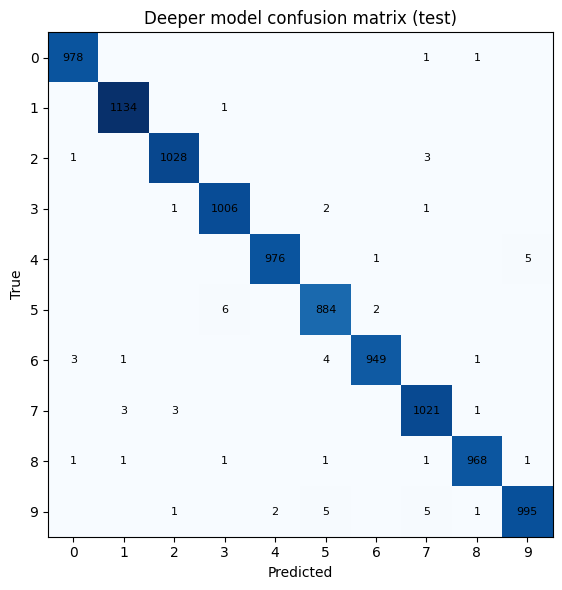

In [10]:
# Deeper model training (added conv layers)
# Trained for the same 10 epochs
deep_model = DeeperMNISTCNN(dropout_p=0.5, activation="relu")
print(deep_model)

deep_model, deep_hist = train_model(
    deep_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=1e-3,
)

print("Avg seconds/epoch:", float(np.mean(deep_hist["epoch_seconds"])))
print("Last val accuracy:", float(deep_hist["val_acc"][-1]))

deep_test_acc, deep_cm = evaluate_and_confusion(deep_model, test_loader, num_classes=10)
print(f"Deeper model test accuracy: {deep_test_acc:.4f}")
plot_confusion_matrix(deep_cm, title="Deeper model confusion matrix (test)")

In [11]:
# experiments: batch size + activation functions

# To keep this notebook lightweight,
# I run a short training and compare validation accuracy + time/epoch

EXPERIMENT_EPOCHS = 3

batch_sizes = [64, 128, 256]
activations = ["relu", "leaky_relu"]

results = []

# Batch size sweep (keep activation fixed: ReLU)
for bs in batch_sizes:
    tr_loader, va_loader, _ = make_loaders(batch_size=bs)
    m = DeeperMNISTCNN(dropout_p=0.5, activation="relu")
    _, h = train_model(m, tr_loader, va_loader, epochs=EXPERIMENT_EPOCHS, lr=1e-3)
    results.append(
        {
            "experiment": "batch_size",
            "batch_size": bs,
            "activation": "relu",
            "val_acc_last": float(h["val_acc"][-1]),
            "sec_per_epoch_avg": float(np.mean(h["epoch_seconds"])),
        }
    )

# Activation sweep (keep batch size fixed: 64)
for act in activations:
    tr_loader, va_loader, _ = make_loaders(batch_size=64)
    m = DeeperMNISTCNN(dropout_p=0.5, activation=act)
    _, h = train_model(m, tr_loader, va_loader, epochs=EXPERIMENT_EPOCHS, lr=1e-3)
    results.append(
        {
            "experiment": "activation",
            "batch_size": 64,
            "activation": act,
            "val_acc_last": float(h["val_acc"][-1]),
            "sec_per_epoch_avg": float(np.mean(h["epoch_seconds"])),
        }
    )

results

Epoch 01/3 | train acc=0.9477 | val acc=0.9833 | 20.5s
Epoch 02/3 | train acc=0.9786 | val acc=0.9888 | 19.8s
Epoch 03/3 | train acc=0.9832 | val acc=0.9918 | 19.5s
Epoch 01/3 | train acc=0.9378 | val acc=0.9870 | 17.3s
Epoch 02/3 | train acc=0.9776 | val acc=0.9882 | 17.6s
Epoch 03/3 | train acc=0.9838 | val acc=0.9897 | 17.4s
Epoch 01/3 | train acc=0.9234 | val acc=0.9863 | 16.5s
Epoch 02/3 | train acc=0.9777 | val acc=0.9902 | 16.4s
Epoch 03/3 | train acc=0.9816 | val acc=0.9905 | 16.8s
Epoch 01/3 | train acc=0.9438 | val acc=0.9812 | 20.0s
Epoch 02/3 | train acc=0.9781 | val acc=0.9897 | 20.2s
Epoch 03/3 | train acc=0.9828 | val acc=0.9893 | 19.7s
Epoch 01/3 | train acc=0.9489 | val acc=0.9862 | 20.5s
Epoch 02/3 | train acc=0.9813 | val acc=0.9920 | 19.5s
Epoch 03/3 | train acc=0.9854 | val acc=0.9913 | 19.8s


[{'experiment': 'batch_size',
  'batch_size': 64,
  'activation': 'relu',
  'val_acc_last': 0.9918333333333333,
  'sec_per_epoch_avg': 19.911938100000345},
 {'experiment': 'batch_size',
  'batch_size': 128,
  'activation': 'relu',
  'val_acc_last': 0.9896666666666667,
  'sec_per_epoch_avg': 17.429740366666618},
 {'experiment': 'batch_size',
  'batch_size': 256,
  'activation': 'relu',
  'val_acc_last': 0.9905,
  'sec_per_epoch_avg': 16.559209866666606},
 {'experiment': 'activation',
  'batch_size': 64,
  'activation': 'relu',
  'val_acc_last': 0.9893333333333333,
  'sec_per_epoch_avg': 19.977188133332977},
 {'experiment': 'activation',
  'batch_size': 64,
  'activation': 'leaky_relu',
  'val_acc_last': 0.9913333333333333,
  'sec_per_epoch_avg': 19.96001463333323}]

## Observations

Baseline vs deeper model:
The baseline CNN (Part A model) trained fast and reached a strong validation accuracy by the end of 10 epochs (last val acc = 0.9875). The baseline test accuracy was 0.9867.

The deeper CNN took longer per epoch but performed a little better overall (last val acc = 0.9942, test accuracy = 0.9939). From the confusion matrices, most predictions are on the diagonal and the remaining mistakes are just a small number of visually similar digits.

Batch size experiments (3 epochs, deeper model, ReLU):
- batch_size = 64: last val acc = 0.9918, avg time/epoch ≈ 19.9s
- batch_size = 128: last val acc = 0.9897, avg time/epoch ≈ 17.4s
- batch_size = 256: last val acc = 0.9905, avg time/epoch ≈ 16.6s

My takeaway is that increasing batch size made each epoch faster (fewer batches per epoch), but validation accuracy stayed about the same across 64/128/256 for this short run.

Activation experiments (3 epochs, deeper model, batch_size = 64):
- ReLU: last val acc = 0.9893, avg time/epoch ≈ 20.0s
- LeakyReLU: last val acc = 0.9913, avg time/epoch ≈ 20.0s

For my run, LeakyReLU was slightly better on validation accuracy and the timing was basically identical.

## Written questions

### What is the difference between epoch and batch?
An epoch is one full pass through the training dataset. A batch is a smaller chunk of the training set used for one update step. So during one epoch, the model goes through many batches.

### How does batch size affect training time and performance?
For training time, larger batch sizes usually mean fewer batches per epoch, so epochs can run faster. The downside is that each step uses more memory and can become slower if it’s too big for the GPU.

For performance, smaller batches can sometimes generalize a little better because the gradient is noisier (kind of like regularization). Larger batches can still work well, but sometimes you have to tune the learning rate to get the best result.

### What is the purpose of the max pooling layer?
Max pooling down-samples the feature maps (reduces width/height). This makes the network faster and reduces the number of parameters later on. It also helps the model be less sensitive to small shifts in the image by keeping the strongest activation in each region.

### What is the purpose of a validation set in your dataset?
The validation set is a held-out part of the training data used to check how well the model is doing on data it wasn’t directly trained on. It helps with choosing the model/hyperparameters and seeing if the model is overfitting (training accuracy keeps improving while validation stops improving or gets worse).

## Acknowledgment

I used a coding assistant (ChatGPT in Cursor, GPT‑5.2) to help scaffold and organize this notebook.